**Import Libraries**

In [1]:
!pip install transformers datasets accelerate torch pandas numpy

In [2]:
import pandas as pd
import numpy as np

import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

**Load Dataset**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Combined Data.csv")

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


**Dataset Information**

In [4]:
print(df.shape)

print(df.columns)

df.info()

(53043, 3)
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


**Check Missing Values**

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
statement,362
status,0


**Remove Missing Data**

In [6]:
df = df.dropna()

df.shape

(52681, 3)

**Check Mental Health Categories**

In [7]:
df['status'].value_counts()

,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


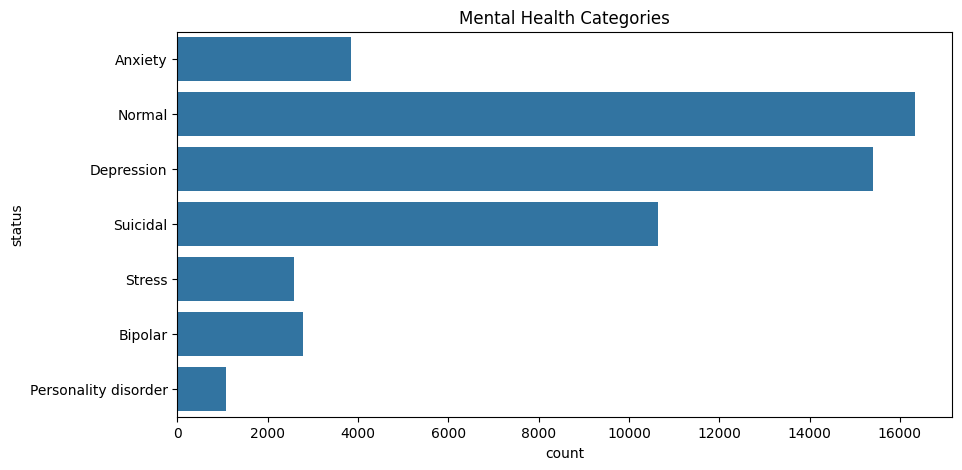

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,5))

sns.countplot(
    y=df['status']
)

plt.title("Mental Health Categories")

plt.show()

**Prepare Dataset For Fine-Tuning**

User:
I feel lonely and depressed

Assistant:
I understand that you are feeling depressed. You are not alone. Talking to someone you trust may help.

In [9]:
def create_training_text(row):

    text = f"""
User:
{row['statement']}

Assistant:
I understand that you are feeling {row['status']}.
Your feelings are important. Try to talk with someone you trust and take care of yourself.
"""

    return text

In [10]:
df['text'] = df.apply(
    create_training_text,
    axis=1
)

df[['text']].head()

,text
0,\nUser:\noh my gosh\n\nAssistant:\nI understan...
1,"\nUser:\ntrouble sleeping, confused mind, rest..."
2,"\nUser:\nAll wrong, back off dear, forward dou..."
3,\nUser:\nI've shifted my focus to something el...
4,"\nUser:\nI'm restless and restless, it's been ..."


**Convert To HuggingFace Dataset**

In [11]:
dataset = Dataset.from_pandas(
    df[['text']]
)

dataset

Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 52681
})

**Load DistilGPT2**

In [12]:
model_name = "distilgpt2"


tokenizer = AutoTokenizer.from_pretrained(
    model_name
)


model = AutoModelForCausalLM.from_pretrained(
    model_name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

**Add Padding Token**

In [13]:
tokenizer.pad_token = tokenizer.eos_token

**Tokenization**

In [14]:
def tokenize(batch):

    return tokenizer(
        batch['text'],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [15]:
tokenized_dataset = dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/52681 [00:00<?, ? examples/s]

**Train/Test Split**

In [16]:
split = tokenized_dataset.train_test_split(
    test_size=0.1
)


train_dataset = split['train']

test_dataset = split['test']

**Data Collator**

In [17]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

**Training Arguments**

In [18]:
training_args = TrainingArguments(

    output_dir="./mental_health_chatbot",

    num_train_epochs=2,

    per_device_train_batch_size=4,

    save_steps=500,

    save_total_limit=2,

    logging_steps=100,

    report_to="none"
)

**Trainer**

In [19]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    data_collator=data_collator
)

**Fine-Tune Model**

In [ ]:
trainer.train()

**Save Model**

In [ ]:
model.save_pretrained(
    "men tal_health_model"
)

tokenizer.save_pretrained(
    "mental_health_model"
)

**Load Fine Tuned Model**

In [ ]:
from transformers import pipeline


chatbot = pipeline(
    "text-generation",
    model="./mental_health_model",
    tokenizer="./mental_health_model",
    device=0
)

**Create Chatbot Function**

In [ ]:
def mental_health_bot(message):

    prompt=f"""

User:
{message}

Assistant:

"""


    response = chatbot(
        prompt,
        max_new_tokens=80,
        temperature=0.7,
        do_sample=True
    )


    return response[0]['generated_text']

**Test Chatbot**

In [ ]:
print(
mental_health_bot(
"I feel very stressed because of my studies"
)
)

In [ ]:
print(
mental_health_bot(
"I feel lonely and anxious"
)
)

**Interactive Chat**

In [ ]:
while True:

    msg=input("You: ")

    if msg=="exit":
        break


    print(
        "Bot:",
        mental_health_bot(msg)
    )

**Conclusion**

A mental health support chatbot was developed using a fine-tuned DistilGPT2 model.

The model was trained on mental health statements and learned to generate supportive and empathetic responses.

The chatbot focuses on:
- Emotional support
- Empathetic tone
- Stress and anxiety related conversations

The model should not replace professional mental healthcare.